In [1]:
import torch
import CT.Models.misc as misc
import CT.Inference.Kolmogorov.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Emu_file_path = '/scratch/ql2221/Emulator_models/wandb_data/wandb/run-20251028_103612-lmys64ex/files/checkpoint_best.p'
Emu = misc.load_model(Emu_file_path).to(device)

CT_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20251214_061257-chnh9042/files/checkpoint_last.p"
CT = misc.load_Conditional_diffusion(CT_file_path).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)
/ext3/miniforge3/lib/p

In [2]:
CT.config

{'model_type': 'ModernUnetRegressor',
 'input_channels': 2,
 'output_channels': 1,
 'hidden_channels': 64,
 'norm': False,
 'dim_mults': [2, 2, 2],
 'n_blocks': 2,
 'mid_attn': False,
 'is_attn': (False, False, False, False),
 'activation': 'gelu',
 'image_width': 64,
 'image_height': 64,
 'first_embedding_dim': None,
 'noise_short_lag': False,
 'different_noise': False,
 'second_embedding_dim': None,
 'third_embedding_dim': None,
 'save_path': '/scratch/ql2221/CT_models/wandb_data/wandb/run-20251214_061257-chnh9042/files',
 'save_name': 'model_weights.pt',
 'diffusion_steps': 100,
 'regression_output_dim': 100,
 'project': 'CT',
 'wandb_run_name': '12/14_100steps_ACDM',
 'wandb_log_freq': 100,
 'ddp': False,
 'PDE': 'Kolmogorov',
 'file_path': '/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ACDM_training_data.p',
 'subsample': None,
 'train_ratio': 0.95,
 'loader_workers': 0,
 'regression_loss_weight': 1,
 'optimization': {'epochs': 200,
  'lr': 0.0002,
  'wd': 0.05,
  'batch_si

In [3]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p")
data = data_dict["data"].to(device)
x = data/4.44

/state/partition1/job-357275/ipykernel_3211713/3435096719.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flo

In [4]:
def CD_only_emu(ics, CD, n_steps, inject_noise_level = 10, silence = False):
    state_vector=torch.zeros((len(ics),n_steps,64,64),device=ics.device)
    
    state_vector[:,0:1]=ics
    state_vector=state_vector.to(ics.device)

    with torch.no_grad(): 
        for aa in tqdm(range(1,n_steps),disable=silence):
            x_t_short_lag = state_vector[:,aa-1].unsqueeze(1)
            new_conditional = torch.cat((x_t_short_lag,x_t_short_lag), dim = 1)
            if inject_noise_level is not None:
                new_conditional[:,-1:]+=inject_noise_level*torch.randn_like(new_conditional[:,-1:],device=ics.device)
            
            pred_noise_level = CD.model.ratio_class(new_conditional).to(ics.device)
            state_vector[:,aa]=CD.denoising(new_conditional, pred_noise_level, stop=-1, forward_diff=True).squeeze()
    return state_vector

In [4]:
rollout = performance.one_step_conditioning(x[:,0:1], Emu, CT = CT, n_steps=30000, short_lag_int = 1, freq = 5, lag_ratio = 5, silence=False, sigma=None, s_init = 3)

100%|██████████| 29999/29999 [04:35<00:00, 109.04it/s]


In [11]:
rollout = CD_only_emu(x[:,0:1], CT, n_steps = 1000, inject_noise_level = 0.4, silence = False)

100%|██████████| 999/999 [02:25<00:00,  6.88it/s]


In [11]:
rollout = rollout[:,:]
make_movie(rollout, save_path="/home/ql2221/Projects/CT/CT/Notebook/rollout.mp4", fps=30)

/state/partition1/job-357275/ipykernel_3179354/3154403748.py:31: UserWarning: frames=<generator object make_movie.<locals>.frame_generator at 0x14f2c9c8c310> which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(fig,update,frames=frame_generator(),blit=False,repeat=False)
Building frames: 100%|██████████| 100/100 [01:01<00:00,  1.62it/s]


movie saved: /home/ql2221/Projects/CT/CT/Notebook/rollout.mp4


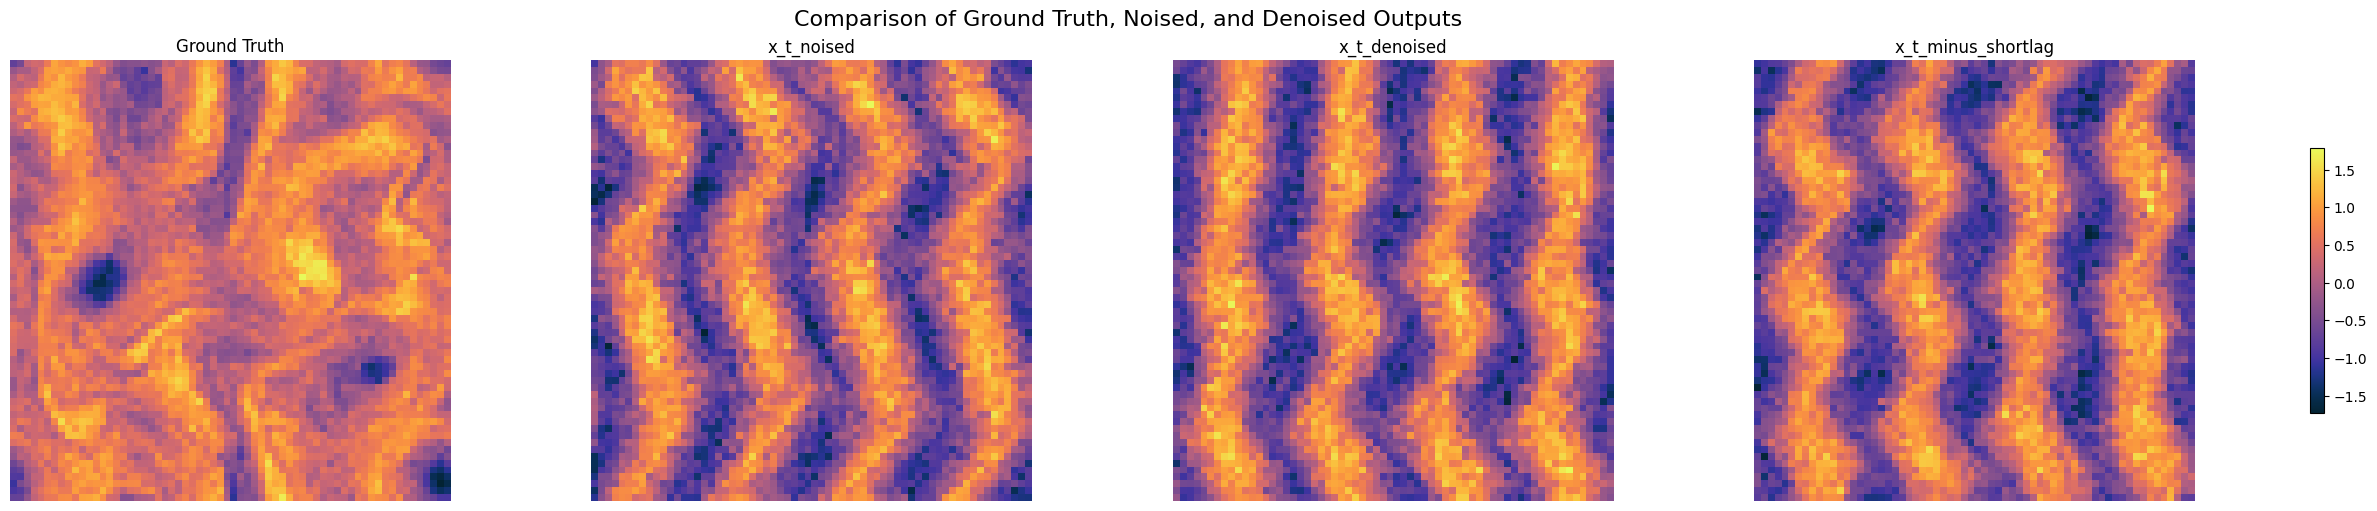

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
a = 0
tensors = [
    rollout[a:a+1,100:101],                
    rollout[a+1:a+2,-1:],
    rollout[a+2:a+3,-1:],
    rollout[a+3:a+4,-1:],
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.show()
